# Adult Dataset: Experiment Results Analysis (Rebuilt)

This notebook loads the `.npy` result files from the Adult dataset experiments, aggregates the metrics across different random seeds, and generates summary tables and plots. This is a rebuilt version based on the verified data structure.

In [12]:
# pip install all numpy pandas matplotlib seaborn

! pip install numpy pandas matplotlib seaborn tabulate

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from IPython.display import display, Markdown

# --- Configuration ---
# Directory where your .npy result files are stored.
RESULTS_DIR = 'tests/results/Adult/'

# List of random seeds used in the experiments.
SEEDS = [6, 12, 13, 523, 972394]

# Define the experiments, their display names, and the file prefixes.
EXPERIMENTS = {
    'Baselines': [
        ('MAP', 'map_baseline'),
        ('LA', 'laplace_ll_baseline'),
        ('LA*', 'laplace_star_baseline'),
        ('Subspace LA', 'subspace_baseline'),
        ('SWAG-Laplace', 'swag_laplace_baseline'),
    ],
    'Domain Shift': [
        ('Shift: Male-to-Female', 'shift_male_to_female'),
        ('Shift: Female-to-Male', 'shift_female_to_male'),
    ],
    'Noise Intensity': [
        ('Noise: 0.1', 'noise_0.1'),
        ('Noise: 0.25', 'noise_0.25'),
        ('Noise: 0.5', 'noise_0.5'),
        ('Noise: 0.75', 'noise_0.75'),
        ('Noise: 1.0', 'noise_1.0'),
    ]
}

# Define the metrics we want to analyze and their corresponding keys in the .npy files.
METRICS_MAP = {
    'Accuracy': 'acc',
    'NLL': 'nll',
    'ECE': 'ece',
    'Confidence': 'conf'
}

In [14]:
def load_and_aggregate_results():
    """
    Loads all .npy result files, groups them by experiment category,
    and computes the mean and standard deviation of key metrics across all seeds.
    """
    aggregated_results = {}
    print("Starting data loading and aggregation...")

    for category, experiments_in_category in EXPERIMENTS.items():
        for display_name, file_prefix in experiments_in_category:
            
            raw_metrics_for_experiment = defaultdict(list)

            for seed in SEEDS:
                filename = f"{file_prefix}_seed{seed}.npy"
                file_path = os.path.join(RESULTS_DIR, filename)

                if os.path.exists(file_path):
                    try:
                        raw_data = np.load(file_path, allow_pickle=True)
                        metrics_dict = raw_data[0] # The dictionary is the first element

                        for display_metric, key in METRICS_MAP.items():
                            if key in metrics_dict:
                                raw_metrics_for_experiment[display_metric].append(metrics_dict[key])
                            else:
                                print(f"Warning: Metric key '{key}' not found in {filename}.")
                                raw_metrics_for_experiment[display_metric].append(np.nan)
                    except Exception as e:
                        print(f"Error: Could not load or process {filename}. Reason: {e}")
            
            if raw_metrics_for_experiment:
                summary = {}
                for metric, values in raw_metrics_for_experiment.items():
                    valid_values = [v for v in values if v is not None and not np.isnan(v)]
                    if valid_values:
                        summary[f'{metric}_mean'] = np.mean(valid_values)
                        summary[f'{metric}_std'] = np.std(valid_values)
                    else:
                        summary[f'{metric}_mean'] = np.nan
                        summary[f'{metric}_std'] = np.nan
                
                aggregated_results[(category, display_name)] = summary

    print("Aggregation complete.")
    return aggregated_results

# Run the function and convert the results dictionary to a DataFrame.
all_results = load_and_aggregate_results()
results_list = [
    {'Category': category, 'Experiment': name, **metrics} 
    for (category, name), metrics in all_results.items()
]
df = pd.DataFrame(results_list)

print("DataFrame created successfully.")
display(df.head())

Starting data loading and aggregation...
Aggregation complete.
DataFrame created successfully.


,Category,Experiment,Accuracy_mean,Accuracy_std,NLL_mean,NLL_std,ECE_mean,ECE_std,Confidence_mean,Confidence_std
0,Baselines,MAP,0.342737,0.208202,0.744736,0.047345,0.305057,0.040027,0.547750,0.032516
1,Baselines,LA,0.342737,0.208202,0.738496,0.041532,0.300837,0.036377,0.542417,0.028804
2,Baselines,LA*,0.342696,0.208120,0.736587,0.040027,0.298528,0.034320,0.540605,0.027738
3,Baselines,Subspace LA,0.342758,0.208192,0.744705,0.047315,0.305034,0.040005,0.547722,0.032494
4,Baselines,SWAG-Laplace,0.853312,0.000859,0.361278,0.006538,0.060116,0.002005,0.888029,0.000869


In [15]:
def create_markdown_tables(results_df):
    """
    Loops through each experiment category and formats the results
    as a clean Markdown table for display.
    """
    for category in EXPERIMENTS.keys():
        display(Markdown(f'### {category} Results'))
        
        category_df = results_df[results_df['Category'] == category].copy()
        
        if category_df.empty:
            print(f"No results to display for category: {category}")
            continue

        # Format the mean ± std string for each metric
        for metric in METRICS_MAP.keys():
            mean_col = f'{metric}_mean'
            std_col = f'{metric}_std'
            
            if mean_col in category_df.columns and std_col in category_df.columns:
                category_df[metric] = category_df.apply(
                    lambda row: f"{row[mean_col]:.4f} ± {row[std_col]:.4f}"
                                if pd.notna(row[mean_col]) else "N/A",
                    axis=1
                )
        
        # Select and order columns for the final display
        display_cols = ['Experiment'] + list(METRICS_MAP.keys())
        display_df = category_df[display_cols]
        
        # Display the formatted DataFrame as a Markdown table
        display(Markdown(display_df.to_markdown(index=False)))


# Generate and display all tables
create_markdown_tables(df)

### Baselines Results

| Experiment   | Accuracy        | NLL             | ECE             | Confidence      |
|:-------------|:----------------|:----------------|:----------------|:----------------|
| MAP          | 0.3427 ± 0.2082 | 0.7447 ± 0.0473 | 0.3051 ± 0.0400 | 0.5478 ± 0.0325 |
| LA           | 0.3427 ± 0.2082 | 0.7385 ± 0.0415 | 0.3008 ± 0.0364 | 0.5424 ± 0.0288 |
| LA*          | 0.3427 ± 0.2081 | 0.7366 ± 0.0400 | 0.2985 ± 0.0343 | 0.5406 ± 0.0277 |
| Subspace LA  | 0.3428 ± 0.2082 | 0.7447 ± 0.0473 | 0.3050 ± 0.0400 | 0.5477 ± 0.0325 |
| SWAG-Laplace | 0.8533 ± 0.0009 | 0.3613 ± 0.0065 | 0.0601 ± 0.0020 | 0.8880 ± 0.0009 |

### Domain Shift Results

| Experiment            | Accuracy        | NLL             | ECE             | Confidence      |
|:----------------------|:----------------|:----------------|:----------------|:----------------|
| Shift: Male-to-Female | 0.7342 ± 0.3125 | 0.6740 ± 0.0391 | 0.3777 ± 0.0244 | 0.5269 ± 0.0068 |
| Shift: Female-to-Male | 0.6385 ± 0.0981 | 0.6806 ± 0.0114 | 0.1462 ± 0.0417 | 0.5204 ± 0.0138 |

### Noise Intensity Results

| Experiment   | Accuracy        | NLL             | ECE             | Confidence      |
|:-------------|:----------------|:----------------|:----------------|:----------------|
| Noise: 0.1   | 0.3426 ± 0.2079 | 0.7385 ± 0.0416 | 0.3007 ± 0.0367 | 0.5424 ± 0.0288 |
| Noise: 0.25  | 0.3421 ± 0.2070 | 0.7386 ± 0.0417 | 0.3002 ± 0.0373 | 0.5425 ± 0.0289 |
| Noise: 0.5   | 0.3417 ± 0.2060 | 0.7389 ± 0.0422 | 0.2997 ± 0.0384 | 0.5428 ± 0.0291 |
| Noise: 0.75  | 0.3414 ± 0.2040 | 0.7393 ± 0.0430 | 0.2977 ± 0.0403 | 0.5431 ± 0.0296 |
| Noise: 1.0   | 0.3419 ± 0.2020 | 0.7398 ± 0.0440 | 0.2955 ± 0.0423 | 0.5436 ± 0.0301 |


--- Creating Plots ---
Saved noise intensity plot to adult_noise_intensity_plot.png


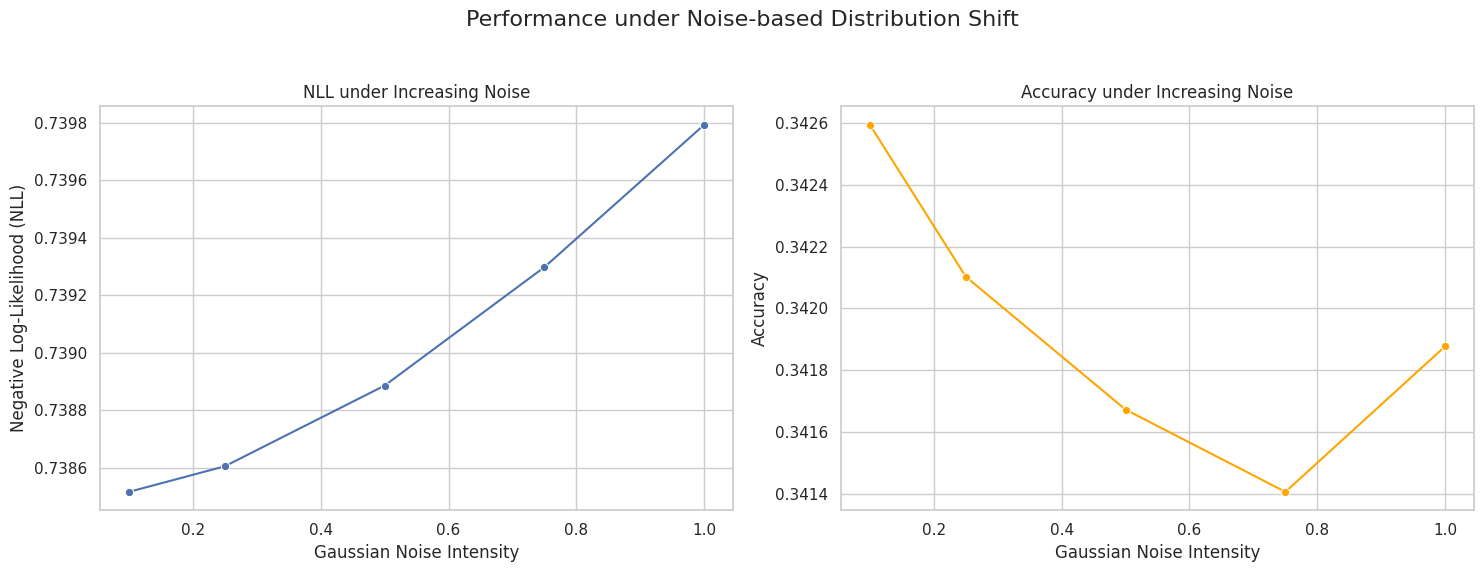

/tmp/ipykernel_16760/3824696269.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shift_df, x='Experiment', y='Accuracy_mean', ax=axes[0], palette='mako')
/tmp/ipykernel_16760/3824696269.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shift_df, x='Experiment', y='NLL_mean', ax=axes[1], palette='viridis')


Saved domain shift plot to adult_domain_shift_plot.png


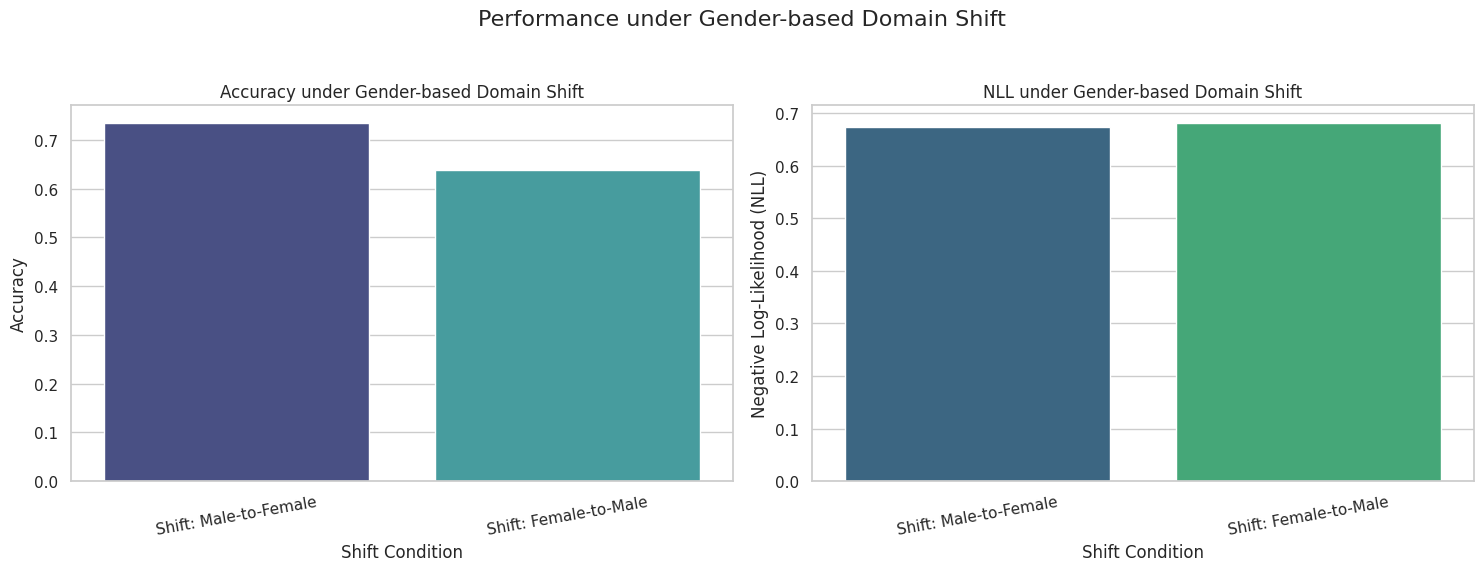

In [16]:
def create_plots(results_df):
    """
    Generates and saves plots for the 'Noise Intensity' and 'Domain Shift' experiments.
    """
    print("\n--- Creating Plots ---")
    sns.set_theme(style="whitegrid")

    # --- Plot 1: Noise Intensity ---
    noise_df = results_df[results_df['Category'] == 'Noise Intensity'].copy()
    if not noise_df.empty:
        # Extract the numeric intensity from the experiment name for the x-axis.
        noise_df['Intensity'] = noise_df['Experiment'].str.extract(r'(\d+\.?\d*)').astype(float)
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Plot NLL vs. Noise Intensity
        sns.lineplot(data=noise_df, x='Intensity', y='NLL_mean', marker='o', ax=axes[0])
        axes[0].set_title('NLL under Increasing Noise')
        axes[0].set_xlabel('Gaussian Noise Intensity')
        axes[0].set_ylabel('Negative Log-Likelihood (NLL)')

        # Plot Accuracy vs. Noise Intensity
        sns.lineplot(data=noise_df, x='Intensity', y='Accuracy_mean', marker='o', ax=axes[1], color='orange')
        axes[1].set_title('Accuracy under Increasing Noise')
        axes[1].set_xlabel('Gaussian Noise Intensity')
        axes[1].set_ylabel('Accuracy')

        fig.suptitle('Performance under Noise-based Distribution Shift', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig('adult_noise_intensity_plot.png')
        print("Saved noise intensity plot to adult_noise_intensity_plot.png")
        plt.show()
    else:
        print("No data for Noise Intensity plot.")

    # --- Plot 2: Domain Shift ---
    shift_df = results_df[results_df['Category'] == 'Domain Shift'].copy()
    if not shift_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # Plot Accuracy under Gender Shift
        sns.barplot(data=shift_df, x='Experiment', y='Accuracy_mean', ax=axes[0], palette='mako')
        axes[0].set_title('Accuracy under Gender-based Domain Shift')
        axes[0].set_xlabel('Shift Condition')
        axes[0].set_ylabel('Accuracy')
        axes[0].tick_params(axis='x', rotation=10)

        # Plot NLL under Gender Shift
        sns.barplot(data=shift_df, x='Experiment', y='NLL_mean', ax=axes[1], palette='viridis')
        axes[1].set_title('NLL under Gender-based Domain Shift')
        axes[1].set_xlabel('Shift Condition')
        axes[1].set_ylabel('Negative Log-Likelihood (NLL)')
        axes[1].tick_params(axis='x', rotation=10)
        
        fig.suptitle('Performance under Gender-based Domain Shift', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig('adult_domain_shift_plot.png')
        print("Saved domain shift plot to adult_domain_shift_plot.png")
        plt.show()
    else:
        print("No data for Domain Shift plot.")

# Generate and display the plots
create_plots(df)